# JUMP-Lite

{func}`~mantispy.ds.jump_lite` reads JUMP-Lite Target-2 {cite:p}`Munoz_2026`: four plates of the JUMP Target-2
plate map, one from each of four laboratories, with the same 1,536 wells measured six ways. Four are learned
embeddings, one is the same architecture as one of them with untrained weights, and `cp_measure` is a
CellProfiler-equivalent feature set. {func}`~mantispy.ds.jump_lite_targets` returns the RefChemDB gene
annotations of its compounds, in the shape {func}`~mantispy.metrics.known_relationships` reads.

## Source

Three things about how the features were made bound every result computed from them.


- **The images are lossy.** Every one of the six blocks was computed on JPEG-XL medium-quality images. Texture
  measurements and convolutional features are the two things most sensitive to compression, so this is not a
  neutral choice, and it is a property of the benchmark rather than of your screen.
- **One field of view per well.** Full Target-2 acquires nine; JUMP-Lite keeps one. So every cell count below
  is cells *in one field*, and [Bringing your own embedding](../tutorials/data/embeddings.ipynb) says how to
  aggregate a model's per-field output when there is more than one.
- **Only one of the six blocks needed segmentation.** `cp_measure` measures objects, so it needs a nucleus and
  a cell body found for every cell. The five embeddings read the whole field and segment nothing. That is the
  real difference between the embeddings and `cp_measure`, and it cuts both ways.

## Used in

- [Bringing your own embedding](../tutorials/data/embeddings.ipynb)
- [Which measurements moved](../tutorials/phenotypes/which_features_moved.ipynb)
- [Learned embeddings against CellProfiler](../tutorials/multisite/learned_embeddings.ipynb)

In [1]:
import matplotlib.pyplot as plt

import mantispy as mt

mt.ds.JUMP_LITE_MODELS

('openphenom', 'dinov2', 'dinov2_random', 'subcell', 'morphem', 'cp_measure')

In [2]:
adata = mt.ds.jump_lite("openphenom")
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1536 × 384
    obs: 'Metadata_id', 'Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_model', 'Metadata_dataset', 'Metadata_compression', 'Metadata_CellCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

The four batches are four different laboratories running one plate map, which makes this a batch-correction
problem with a clean design: whatever separates `source_3` from `source_6` is not biology, because they
received the same compounds in the same wells.

In [3]:
counts = adata.obs.groupby("Metadata_Source", observed=True).agg(
    plate=("Metadata_Plate", "first"),
    wells=("Metadata_Well", "size"),
    controls=("Metadata_Control", "sum"),
    median_cells=("Metadata_CellCount", "median"),
)
# The controls received no compound, so their counts are the site's own density, before any treatment effect.
counts["median_cells, controls"] = (
    adata.obs[adata.obs["Metadata_Control"]].groupby("Metadata_Source", observed=True)["Metadata_CellCount"].median()
)
counts["compounds"] = adata.obs.groupby("Metadata_Source", observed=True)["Metadata_Perturbation"].nunique()
thin = adata.obs["Metadata_CellCount"] < 50
counts["wells under 50 cells"] = thin.groupby(adata.obs["Metadata_Source"], observed=True).sum()
counts

,plate,wells,controls,median_cells,"median_cells, controls",compounds,wells under 50 cells
Metadata_Source,,,,,,,
source_3,JCPQC016,384,64,264.0,282.0,302,28
source_4,BR00121438,384,64,189.0,210.0,302,61
source_5,ACPJUM012,384,64,336.0,357.0,302,13
source_6,110000293081,384,64,254.0,266.0,302,37


## What it looks like

One number per laboratory hides where the wells are. Four 384-well plates, coloured by how many cells were
found in the field.

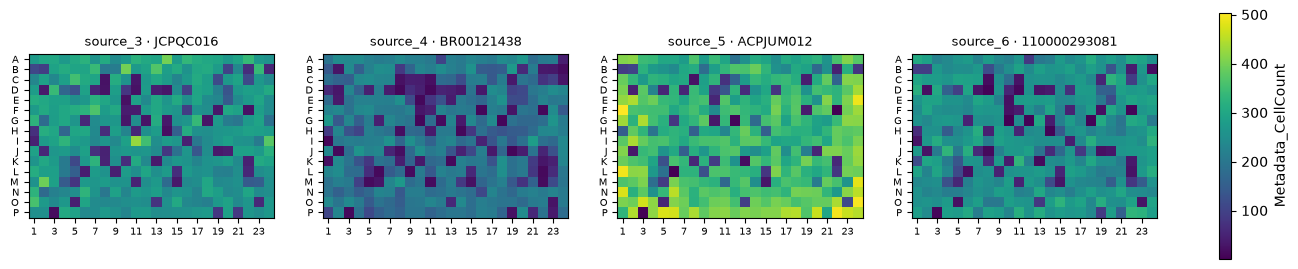

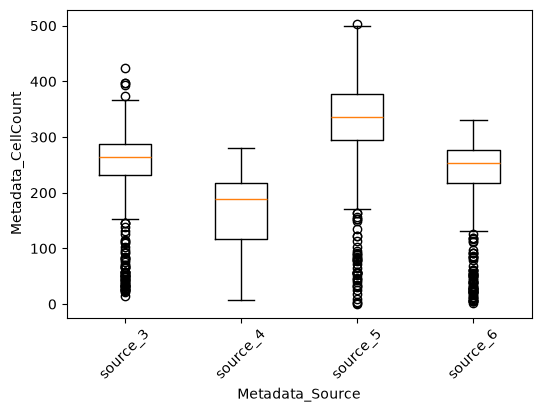

{'share of the plate on the edge': '20%',
 'share of thin wells on the edge': '10%'}

In [4]:
mt.pl.plate(adata, color="Metadata_CellCount", groupby="Metadata_Source", ncols=4)
plt.show()

ax = mt.pl.cell_counts(adata, groupby="Metadata_Source")
plt.show()

row, column = adata.obs["Metadata_Well"].str[0], adata.obs["Metadata_Well"].str[1:].astype(int)
edge = row.isin(["A", "P"]) | column.isin([1, 24])
{
    "share of the plate on the edge": f"{edge.mean():.0%}",
    "share of thin wells on the edge": f"{edge[thin].mean():.0%}",
}

Two facts to know before using it. The sites run at different densities before any compound acts: the
control wells, which received none, hold a median of 210 cells at `source_4` against 357 at `source_5`. And
the thin wells are not banked against the edge, where evaporation would put them — the edge is a fifth of the
plate but holds only a tenth of the thin wells.